# **Binomial Option Pricing Model. A Technical and Didactic Guide**

This notebook presents a complete, hands-on implementation of the **Binomial Option Pricing Model** in Python.  Each section contains detailed theoretical explanations in Markdown + LaTeX, followed by executable Python code.  

The objective is to understand how to price both **European** and **American** options using discrete-time binomial trees, and to explore the impact of volatility, interest rate, and the number of time steps.

---
##  Mathematical Background
Under the risk-neutral measure, the expected return of the underlying equals the risk-free rate $r$.  Over a small time interval $\Delta t = \tfrac{T}{N}$ we define:

$$u = e^{\sigma \sqrt{\Delta t}}, \qquad d = e^{-\sigma \sqrt{\Delta t}},$$

and the **risk-neutral probability** of an up-move:

$$p = \frac{e^{r\Delta t} - d}{u - d}.$$

At maturity, the option value equals its payoff $V_N^j = f(S_N^j)$.  Moving backward through the tree we compute the discounted expected value:

$$V_i^j = e^{-r\Delta t}\,[pV_{i+1}^{j+1} + (1-p)V_{i+1}^j].$$

For an American option we take the maximum between continuation and immediate exercise:

$$V_i^j = \max\bigl(f(S_i^j),\; e^{-r\Delta t}[pV_{i+1}^{j+1}+(1-p)V_{i+1}^j]\bigr).$$

## **Section 1. Importing Required Libraries**

We start by importing the fundamental Python libraries used throughout this notebook.

- **math**: mathematical constants and elementary functions.
- **numpy**: vectorized numerical computation.
- **pandas**: data handling and time-series manipulation.
- **yfinance**: downloading historical price data from Yahoo Finance.
- **matplotlib**: visualization and tree plotting.
- **datetime**: date arithmetic.


In [22]:
import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

## **Section 2. Historical Data Retrieval**

This function retrieves adjusted historical prices from Yahoo Finance.  The parameter `lookback_years` defines how many years of data are used for volatility estimation.

In [37]:
def get_historical_data(ticker, end_date, lookback_years=7):
    """
    Retrieves historical price data from Yahoo Finance for a specified number of past years.
    The 'lookback_years' parameter can be an integer or a decimal (e.g., 2.5 for 2.5 years).
    """
    end_date = pd.to_datetime(end_date)
    # Υπολογισμός ημερών με βάση το πλήθος ετών (365.25 ημέρες ανά έτος)
    days_offset = int(lookback_years * 365.25)
    start_date = end_date - pd.Timedelta(days=days_offset)

    df = yf.download(ticker, start=start_date.strftime('%Y-%m-%d'), end=end_date, auto_adjust=True)
    return df


## **Section 3. Historical Volatility Calculation**

Volatility ($\sigma$) measures the standard deviation of returns.  For daily data we annualize by multiplying by $\sqrt{252}$, assuming 252 trading days per year.

## **Understanding Historical Volatility Calculation**

Volatility, denoted by $\sigma$, measures how much the price of a financial asset fluctuates over time.  
It is a key input in all option pricing models — higher volatility increases the probability that the option will end up in the money, thus increasing its price.

---

### **1️⃣ Step 1 – Compute Log Returns**
We first compute the **daily (or monthly) returns** of the asset:
$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}} = \frac{P_t}{P_{t-1}} - 1
$$
where $P_t$ is the closing price at day $t$.

In the code, this is implemented as:

`df['Returns'] = df['Close'].pct_change()`

---

### **2️⃣ Step 2 – Compute Standard Deviation**
The historical volatility is simply the **standard deviation** of these returns over the observed period:
$$
\sigma_{\text{daily}} = \text{stdev}(R_t)
$$

This daily volatility measures the average relative price variation from one trading day to the next.

---

### **3️⃣ Step 3 – Annualize the Volatility**
Since most financial models (like Black–Scholes and the Binomial model) use **annualized volatility**, we multiply the daily standard deviation by the square root of the number of trading periods in one year:

- For **daily data**, there are about 252 trading days per year:
  $$
  \sigma_{\text{annual}} = \sigma_{\text{daily}} \times \sqrt{252}
  $$
- For **monthly data**, with roughly 12 months per year:
  $$
  \sigma_{\text{annual}} = \sigma_{\text{monthly}} \times \sqrt{12}
  $$

---

### **4️⃣ Intuitive Explanation**

This formula comes from the statistical property of the standard deviation of independent returns:  
if daily returns are independent and identically distributed, then
$$
\text{Var}(\text{annual returns}) = 252 \times \text{Var}(\text{daily returns})
$$
and therefore,
$$
\sigma_{\text{annual}} = \sqrt{252} \times \sigma_{\text{daily}}
$$

---

### **5️⃣ Practical Notes**
- Using **adjusted prices** (`auto_adjust=True` in Yahoo Finance) ensures that splits and dividends are correctly accounted for.  
- The historical volatility represents **past variability**, not necessarily the future one — but it serves as a reasonable estimate for the Binomial model.  
- You can experiment with different lookback periods (e.g., 1 year vs. 7 years) to see how volatility evolves over time.


In [38]:
def calculate_volatility(df, period='daily'):
    if period == 'daily':
        df['Returns'] = df['Close'].pct_change()
        volatility = df['Returns'].std() * math.sqrt(252)
    elif period == 'monthly':
        df_monthly = df['Close'].resample('M').last().pct_change()
        volatility = df_monthly.std() * math.sqrt(12)
    else:
        raise ValueError("Unsupported period. Use 'daily' or 'monthly'.")
    return volatility

## **Section 4. Generalized Binomial Model Implementation**

This function implements the full binomial tree algorithm supporting both European and American options.  The optional argument `plot_tree` visualizes the option value lattice.

In [39]:
def binomial_model(
    payoff_func,
    S0=None,
    ticker=None,
    end_date=None,
    K=None,
    T=1,
    r=0.05,
    sigma=None,
    N=100,
    american=True,
    plot_tree=False,
    lookback_years=7  # <-- ΝΕΟ επιχείρημα
):
    """
    Generalized Binomial Option Pricing Model.

    Parameters:
    - payoff_func: Payoff function (St -> float)
    - S0: Initial asset price (if not provided, uses ticker)
    - ticker: Asset symbol (e.g., "AAPL")
    - end_date: End date for data retrieval (e.g., "2025-05-20")
    - K: Strike price
    - T: Time to maturity (in years)
    - r: Risk-free interest rate
    - sigma: Volatility (if None, it will be estimated)
    - N: Number of time steps
    - american: Boolean flag for American vs European option
    - plot_tree: Boolean flag to visualize the binomial tree
    - lookback_years: Number of past years for historical data (default=7)
    """

    # --- 1. Handle input and get data ---
    if S0 is None and ticker:
        df_hist = get_historical_data(ticker, end_date, lookback_years)
        S0 = df_hist['Close'].iloc[-1]
        if sigma is None:
            sigma = calculate_volatility(df_hist)
    elif S0 is None:
        raise ValueError("Either S0 or ticker must be provided.")

    # --- 2. Define parameters ---
    dt = T / N
    u = math.exp(sigma * math.sqrt(dt))
    d = 1 / u
    p = (math.exp(r * dt) - d) / (u - d)

    if not (0 <= p <= 1):
        raise ValueError(f"Invalid risk-neutral probability p={p:.4f}. Try changing N or sigma.")

    # --- 3. Build stock and option trees ---
    stock_tree = [[S0 * (d ** j) * (u ** (i - j)) for j in range(i + 1)] for i in range(N + 1)]
    option_tree = [[0.0 for _ in range(i + 1)] for i in range(N + 1)]

    # --- 4. Payoff at maturity ---
    for j in range(N + 1):
        St = stock_tree[N][j]
        option_tree[N][j] = payoff_func(St, K=K)

    # --- 5. Backward induction ---
    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            hold_value = math.exp(-r * dt) * (p * option_tree[i + 1][j + 1] + (1 - p) * option_tree[i + 1][j])
            if american:
                exercise_value = payoff_func(stock_tree[i][j], K=K)
                option_tree[i][j] = max(hold_value, exercise_value)
            else:
                option_tree[i][j] = hold_value

    price = option_tree[0][0]

    # --- 6. Optional tree visualization ---
    if plot_tree:
        fig, ax = plt.subplots(figsize=(12, 6))
        for i in range(N + 1):
            for j in range(i + 1):
                x, y = i, i - 2 * j
                ax.text(x, y, f"{option_tree[i][j]:.2f}", ha='center', va='center', fontsize=9,
                        bbox=dict(facecolor='lightgreen', alpha=0.7))
                if i < N:
                    ax.plot([x, x + 1], [y, y + 1], 'k-', lw=0.5)
                    ax.plot([x, x + 1], [y, y - 1], 'k-', lw=0.5)
        ax.set_title(f"Option Value Tree ({ticker})")
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    return price


## **Section 5. Example 1: European Call Option on HTZ**

In this first example, we price a European **call** option on the ticker **HTZ** (Hertz).  
The strike price is $K=5.2$, the maturity is $T=0.3$ years, the risk-free rate is $r=4.5\%$, and the number of steps is $N=3$.  
The tree diagram will be displayed automatically.

In [40]:
def call_payoff(St, K):
    if isinstance(St, pd.Series):
        St = St.item()   # Για ασφάλεια σε περίπτωση pandas αντικειμένων
    return np.maximum(St - K, 0)


[*********************100%***********************]  1 of 1 completed


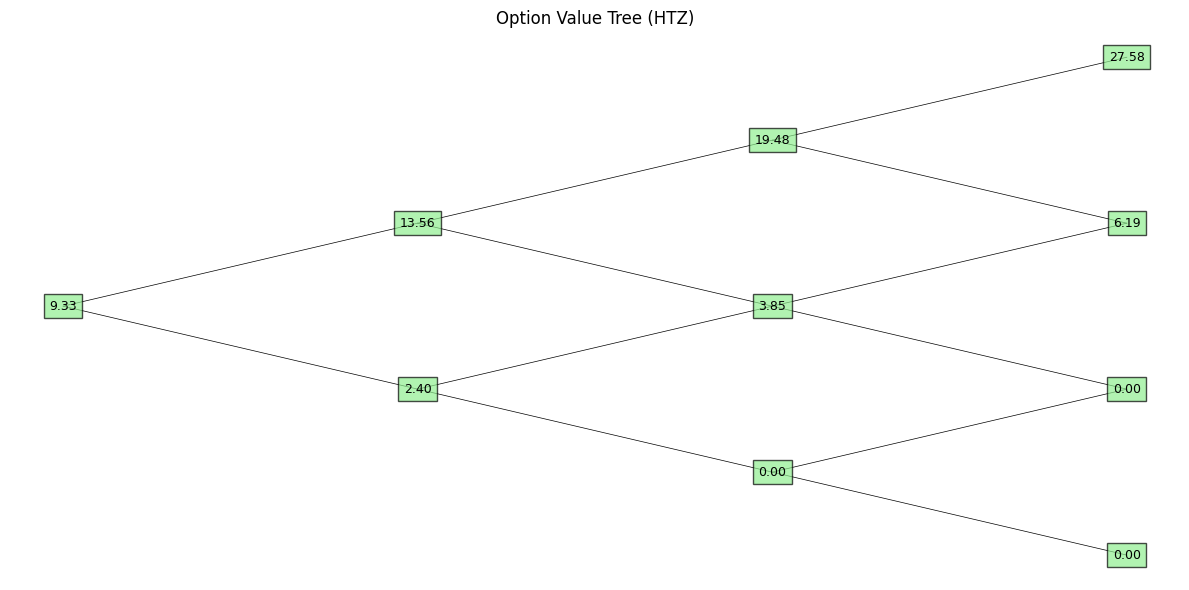

Option Price: 9.3306 (using 0.3 years of historical data)


In [45]:
# Παράδειγμα: European Call option στο HTZ με 2.5 έτη ιστορικά δεδομένα
lookback_years = .3  # ✅ ορίζουμε το πλήθος ετών που θα χρησιμοποιηθούν

price = binomial_model(
    payoff_func=call_payoff,
    ticker="HTZ",
    end_date="2025-05-20",
    K=5.2,
    T=0.3,
    r=0.045,
    N=3,
    american=False,
    plot_tree=True,
    lookback_years=lookback_years  # περνάμε τη μεταβλητή
)

print(f"Option Price: {price:.4f} (using {lookback_years} years of historical data)")


## **Section 6. Example 2: American Put Option on AAPL**

Here we price an **American put** option on Apple Inc. (AAPL).  
Because it is American-style, early exercise is allowed.

[*********************100%***********************]  1 of 1 completed


Columns available in downloaded data for AAPL: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]


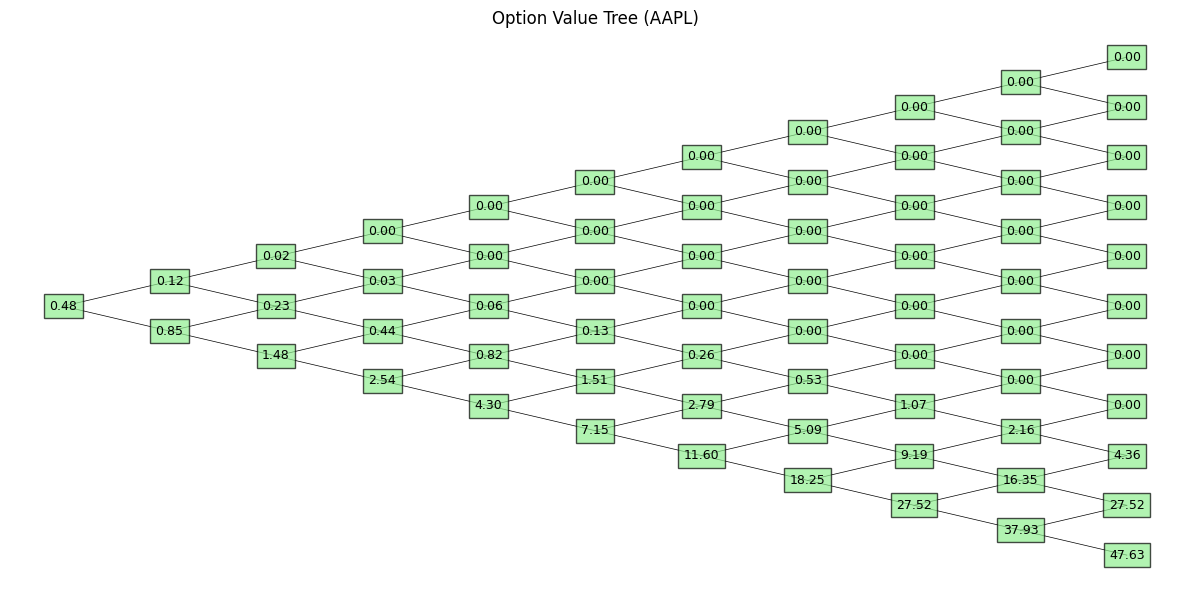

American Put Option (AAPL): 0.4826


In [28]:
def put_payoff(St, K):
    if isinstance(St, pd.Series):
        St = St.item()
    return np.maximum(K - St, 0)

price_aapl = binomial_model(
    payoff_func=put_payoff,
    ticker='AAPL',
    end_date=datetime.today().strftime('%Y-%m-%d'),
    K=180,
    T=0.5,
    r=0.04,
    N=10,
    american=True,
    plot_tree=True
)
print(f'American Put Option (AAPL): {price_aapl:.4f}')

## **Section 7. Example 3: Sensitivity Analysis**

We now examine how the option price changes as we vary key parameters:
- Volatility $\sigma$
- Risk-free rate $r$
- Number of time steps $N$

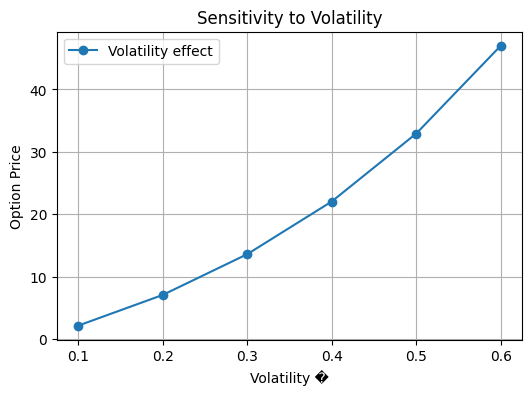

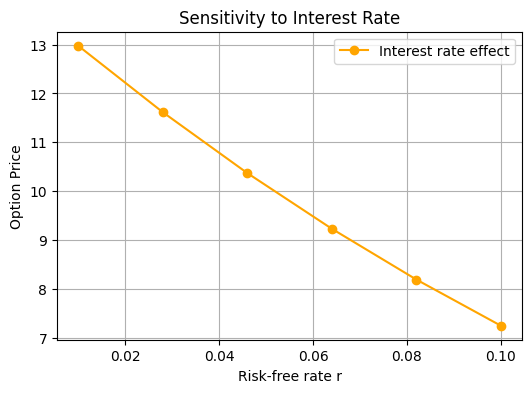

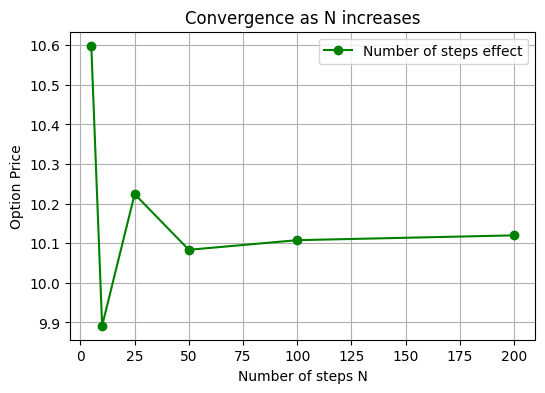

In [12]:
base_sigma = 0.25
sigma_values = np.linspace(0.1, 0.6, 6)
prices_sigma = []

for s in sigma_values:
    price = binomial_model(call_payoff, S0=100, K=100, T=1, r=0.05, sigma=s, N=100, american=False)
    prices_sigma.append(price)

plt.figure(figsize=(6,4))
plt.plot(sigma_values, prices_sigma, 'o-', label='Volatility effect')
plt.xlabel('Volatility �')
plt.ylabel('Option Price')
plt.title('Sensitivity to Volatility')
plt.legend()
plt.grid(True)
plt.show()

# Sensitivity to r
r_values = np.linspace(0.01, 0.1, 6)
prices_r = [binomial_model(call_payoff, S0=100, K=100, T=1, r=r, sigma=base_sigma, N=100, american=False) for r in r_values]
plt.figure(figsize=(6,4))
plt.plot(r_values, prices_r, 'o-', color='orange', label='Interest rate effect')
plt.xlabel('Risk-free rate r')
plt.ylabel('Option Price')
plt.title('Sensitivity to Interest Rate')
plt.legend()
plt.grid(True)
plt.show()

# Sensitivity to N
N_values = [5, 10, 25, 50, 100, 200]
prices_N = [binomial_model(call_payoff, S0=100, K=100, T=1, r=0.05, sigma=base_sigma, N=N, american=False) for N in N_values]
plt.figure(figsize=(6,4))
plt.plot(N_values, prices_N, 'o-', color='green', label='Number of steps effect')
plt.xlabel('Number of steps N')
plt.ylabel('Option Price')
plt.title('Convergence as N increases')
plt.legend()
plt.grid(True)
plt.show()

## **Section 8. Conclusions and Further Work**

In this notebook we have implemented and explored the Binomial Option Pricing Model in detail.  

**Key takeaways:**
1. The binomial model converges to the Black-Scholes price as $N \to \infty$.
2. It naturally handles **American options**, which the closed-form Black-Scholes model cannot.
3. Volatility estimation from historical data provides realistic inputs for market-based pricing.

